In [1]:
#imort libraries

import pandas as pd
import numpy as np

#for correlation matrix 
import seaborn as sns
import matplotlib.pyplot as plt

#to split training and test data 
from sklearn.model_selection import train_test_split

#for linear regression
from sklearn.linear_model import LinearRegression
#for Ridge Regresssion 
from sklearn.linear_model import Ridge

#for metrics ;  R2, RMSE, and MAE
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

#1. Load the data as a Pandas data frame and ensure that it imported correctly.
#read data file 
url = 'auto-mpg.csv'
df = pd.read_csv(url)
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [2]:
#2. Begin by prepping the data for modeling:
#Remove the car name column.
df = df.drop('car name', axis=1)

In [3]:
#The horsepower column values likely imported as a string data type. Figure out why and replace any strings with the column mean.
#check the data type for the horsepower column 
#print(df['horsepower'].dtype)
print(df['horsepower'].unique()) #See a '?' in the unique values- causing the string data type. 
# Replace '?' with NaN
df['horsepower'] = df['horsepower'].replace('?', np.nan)
# convert column to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'])
# calculate the mean without the NaN
mean_hp = df['horsepower'].mean()
# fill the NaN with the mean 
df['horsepower'] = df['horsepower'].fillna(mean_hp)
print(df['horsepower'].dtype) #Looks good

['130' '165' '150' '140' '198' '220' '215' '225' '190' '170' '160' '95'
 '97' '85' '88' '46' '87' '90' '113' '200' '210' '193' '?' '100' '105'
 '175' '153' '180' '110' '72' '86' '70' '76' '65' '69' '60' '80' '54'
 '208' '155' '112' '92' '145' '137' '158' '167' '94' '107' '230' '49' '75'
 '91' '122' '67' '83' '78' '52' '61' '93' '148' '129' '96' '71' '98' '115'
 '53' '81' '79' '120' '152' '102' '108' '68' '58' '149' '89' '63' '48'
 '66' '139' '103' '125' '133' '138' '135' '142' '77' '62' '132' '84' '64'
 '74' '116' '82']
float64


In [4]:
#Create dummy variables for the origin column.
origin_dummies = pd.get_dummies(df['origin'], prefix='origin')

#add to the original dataframe
df = pd.concat([df, origin_dummies], axis=1)

#check 
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,1,True,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,1,True,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,1,True,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,1,True,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,1,True,False,False


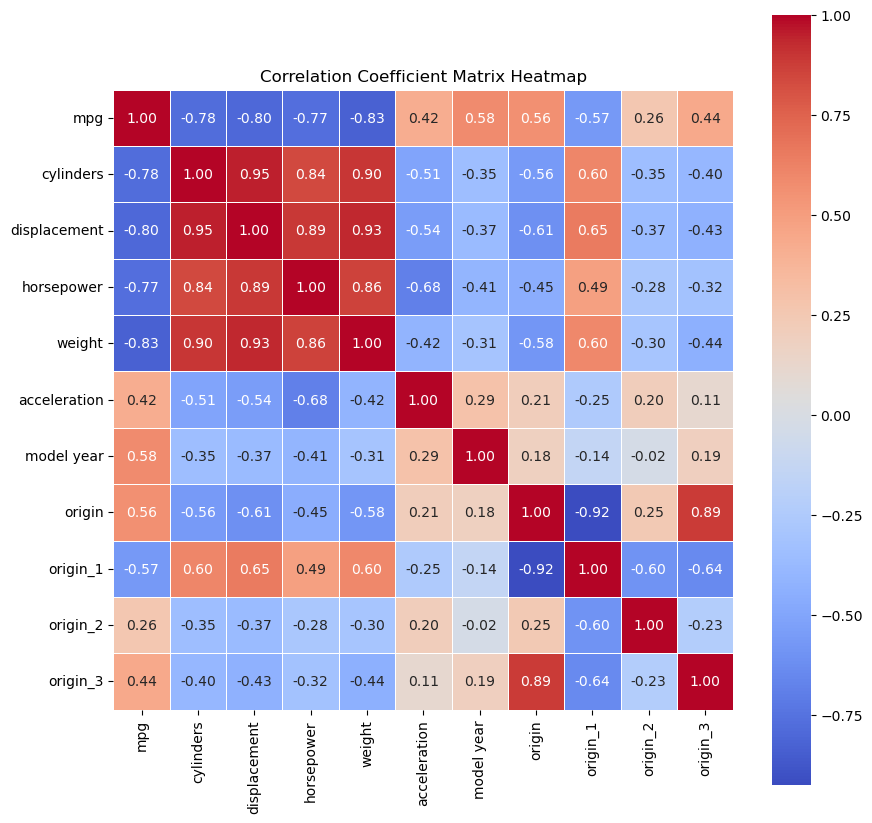

In [5]:
#3. Create a correlation coefficient matrix and/or visualization.

# create the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Set the size
plt.figure(figsize=(10, 10))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

# Title of Correlation coefficient
plt.title("Correlation Coefficient Matrix Heatmap")
plt.show()

#Are there features highly correlated with mpg? The highest negative correlation is -0.83 meaning as one variable increases, the other significantly decreases. 

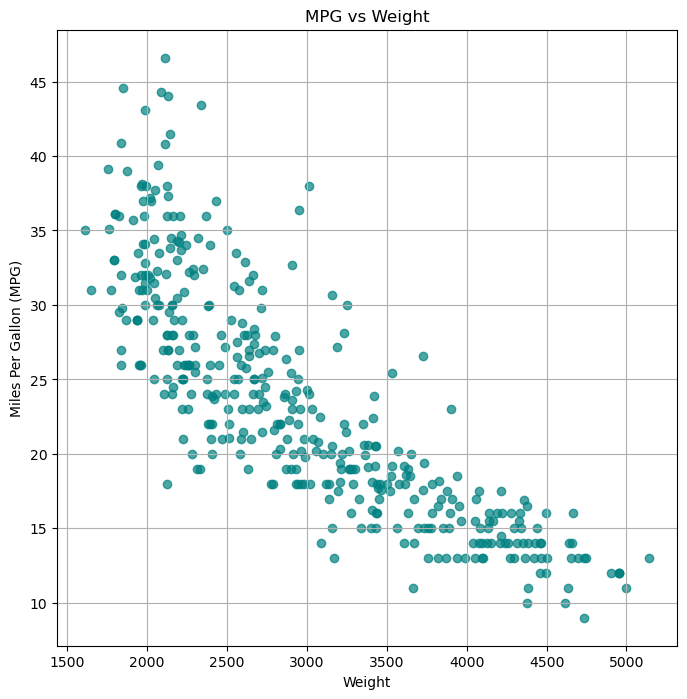

In [6]:
#4. Plot mpg versus weight. Analyze this graph and explain how it relates to the corresponding correlation coefficient.

plt.figure(figsize=(8, 8))
plt.scatter(df['weight'], df['mpg'], alpha=0.7, color='teal')
plt.title('MPG vs Weight')
plt.xlabel('Weight')
plt.ylabel('Miles Per Gallon (MPG)')
plt.grid(True)
plt.show()

#As the weight of the vehicle goes up the MPG goes down. These two variables have a negative correlation. 

In [7]:
#5. Randomly split the data into 80% training data and 20% test data, where your target is mpg.

# Weight as X
X = df.drop(columns=['mpg'])

# Target = 'mpg'
y = df['mpg']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #42 is to recreate the data
  
#change to 2 dimensional 
#X_train = X_train.values.reshape(-1, 1)
#X_test = X_test.values.reshape(-1, 1)

# Optional: Check the shape of the splits
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)    


Training set: (318, 10) (318,)
Test set: (80, 10) (80,)


In [8]:
#6. Train an ordinary linear regression on the training data. Y = mX + c

# Create linear regression
regression = LinearRegression()

# Fit the model on training data
model= regression.fit(X_train, y_train)


In [9]:
c = model.intercept_
c

-21.97126125795512

In [10]:
m = model.coef_
m

array([-0.16373048,  0.01958399, -0.01334457, -0.00707275,  0.07335016,
        0.82739747,  0.88430052, -0.97974802,  1.07519552, -0.0954475 ])

In [11]:
#predict set
y_pred = model.predict(X_test)
y_pred2 = model.predict(X_train)

In [12]:
#7. Calculate R2, RMSE, and MAE on both the training and test sets and interpret your results.

#Test set scores
r2_model = r2_score(y_test, y_pred)
rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
MAE = mean_absolute_error(y_test, y_pred)

print(f'R-squared: {r2_model}')
print(f'Root Mean Squared Error: {rmse_model}')
print(f'MAE: {MAE}')

R-squared: 0.8449006123776618
Root Mean Squared Error: 2.88775734788363
MAE: 2.2875867704421053


In [13]:
#Train set scores
r2_model2 = r2_score(y_train, y_pred2)
rmse_model2 = np.sqrt(mean_squared_error(y_train, y_pred2))
MAE2 = mean_absolute_error(y_train, y_pred2)

print(f'R-squared: {r2_model2}')
print(f'Root Mean Squared Error: {rmse_model2}')
print(f'MAE: {MAE2}')

R-squared: 0.8188288951042786
Root Mean Squared Error: 3.370273563938906
MAE: 2.6054846937710354


In [14]:
# The R-Squared at .81-.84 is a very good fit. 
# The RMSE is a bit high but not so much that overfitting can be identified, overall, it's got about a 2.6 average predication error. 

In [15]:
#8. Pick another regression model and repeat the previous two steps. Note: Do NOT choose logistic regression as it is more like a classification model.
#Regularized Ridge Model 

ridge = Ridge(alpha=.3)
ridge.fit(X_train,y_train)
print ("Ridge model:", (ridge.coef_))

Ridge model: [-0.16272182  0.01952183 -0.01331413 -0.00707148  0.07334279  0.82716518
  0.88269172 -0.97601745  1.06934317 -0.09332572]


In [16]:
#predict set
y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

In [17]:
#Ridge Train set score
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

print(f"R-squared: {r2_train:.4f}")
print(f"Root Mean Squared Error: {rmse_train:.4f}")
print(f"MAE: {mae_train:.4f}")


R-squared: 0.8188
Root Mean Squared Error: 3.3703
MAE: 2.6054


In [18]:
#Ridge Test set score
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"R-squared: {r2_test:.4f}")
print(f"Root Mean Squared Error: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")

R-squared: 0.8449
Root Mean Squared Error: 2.8875
MAE: 2.2872
